In [50]:
import pandas as pd
import numpy as np
from sklearn import metrics
import matplotlib.colors as mcolors
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams, rcParamsDefault

rcParams.update(rcParamsDefault)
rcParams['pdf.fonttype'] = 42
sns.set(context = 'paper' , style='ticks' , 
    rc = {
        'figure.autolayout' : True,
        'font.sans-serif': ['Arial', 'Helvetica'],  # Specify Arial or Helvetica
        'axes.titlesize' : 6 ,
        'axes.titleweight' :'regular',
        
        'figure.titleweight' : 'regular' ,
        'figure.titlesize' : 6 ,
        'figure.labelsize' : 6 ,
        'figure.labelweight' : 'regular' , 
        
        'axes.labelsize' : 6 ,
        'axes.labelpad' : 2 ,
        'axes.labelweight' : 'regular' , 
        'axes.spines.top' : False,
        'axes.spines.right' : False,
        
        'legend.fontsize' : 6 ,
        'figure.figsize' : (8/2.54, 8/2.54) , 
        'figure.dpi': 300,      
        'figure.facecolor': 'w',
        'figure.edgecolor': 'black',   
        'legend.edgecolor': 'black',
        'legend.labelcolor': 'black',  # 设置图例标签字体颜色（在新版matplotlib中支持）
        'axes.edgecolor': 'black',
        'axes.labelcolor': 'black',
        'xtick.color': 'black',
        'ytick.color': 'black',
        'axes.titlecolor': 'black',
        'axes.labelcolor': 'black',

        'xtick.labelsize': 6,
        'ytick.labelsize': 6,
        'xtick.direction' : 'out' ,
        'ytick.direction' : 'out' ,
        'xtick.major.width': 0.5,  # X轴刻度主刻度线宽度
        'ytick.major.width': 0.5, 
        'xtick.major.size' : 2 ,
        'ytick.major.size' : 2 ,
        'xtick.minor.size': 2,  # X-axis minor tick length
        'ytick.minor.size': 2,  # Y-axis minor tick length

        'xtick.major.pad' : 2,
        'ytick.major.pad' : 2,
        'text.color': 'black',  # 全局文字颜色

        'lines.linewidth' : 0.75  , 
        'axes.linewidth': 0.5,  # Axis line width
        'savefig.dpi': 300,  # Save resolution 
        'savefig.bbox': 'tight',  # Tight bounding box       
        }
    )


# COLOR_MAP = {'H3K4me1':'#A28F19','H3K4me3':'#7FA5D0','H3K9me3':'#FDE4A4','H3K27ac':'#F5B6AC','H3K27me3':'#7CA68B','H3K36me3':'#80448A','H3K9ac':'#C7886D'}
COLOR_MAP = {'H3K4me1':'#BB72AC','H3K4me3':'#56B4E6','H3K9me3':'#7CC9C1','H3K27ac':'#EC6D5D','H3K27me3':'#F4DE28','H3K36me3':'#88C463','H3K9ac':'#3D60AC'}

COLORS = ['#39729C', "#D8B66F"]
palette=mcolors.LinearSegmentedColormap.from_list("colormap", COLORS, N=60)


EIDS_TO_CELLTYPES = {
    'E116':'GM12878',
    'E118':'HepG2',
    'E003':'H1'
}



In [51]:
def compute_auc_table(pred_labeled_df, eid):
    """
    Return AUC table with columns:
        eid, fold, auc, target

    Example:
        E116,0,91.61,bs_label
        E116,0,89.96,bf_label
    """
    rows = []

    for fold, sub in pred_labeled_df.groupby("fold"):
        fold = int(fold)

        for target in ["bs_label", "bf_label"]:
            score_col = f"{target}_score"

            valid = sub[[target, score_col]].dropna().copy()

            if valid.empty or valid[target].nunique() < 2:
                auc = np.nan
            else:
                auc = metrics.roc_auc_score(
                    valid[target].astype(int),
                    valid[score_col].astype(float),
                ) * 100

            rows.append({
                "eid": eid,
                "fold": fold,
                "auc": auc,
                "target": target,
            })

    auc_df = pd.DataFrame(rows)

    auc_df = auc_df.sort_values(
        ["eid", "fold", "target"],
        ascending=[True, True, False],  # 让 bs_label 通常排在 bf_label 前面可能不稳定
    ).reset_index(drop=True)

    # 强制按照 bs_label, bf_label 顺序
    target_order = pd.Categorical(
        auc_df["target"],
        categories=["bs_label", "bf_label"],
        ordered=True,
    )
    auc_df["target"] = target_order

    auc_df = auc_df.sort_values(["eid", "fold", "target"]).reset_index(drop=True)
    auc_df["target"] = auc_df["target"].astype(str)

    return auc_df[["eid", "fold", "auc", "target"]]

# txburst

In [52]:
data = pd.DataFrame()

for eid in ['E003','E116','E118']:
    pred_labeled_df = pd.read_csv(f'benchmarks/revised_v2/reviewer1/results/random_tss_selected_gene_predictions_by_fold_{eid}.csv')

    indicator = compute_auc_table(pred_labeled_df, eid)
    data = pd.concat([data,indicator], axis=0)

data['tss'] = 'random_selected'
data2 = pd.read_csv('extra/results/bs_bf_para_indicators.csv')
data2['tss'] = 'origin'
data = pd.concat([data,data2],axis=0)
data['auc'] = data['auc'] / 100


     eid  fold       auc    target              tss
0   E003     0  0.820592  bs_label  random_selected
1   E003     0  0.932956  bf_label  random_selected
2   E003     1  0.805038  bs_label  random_selected
3   E003     1  0.942732  bf_label  random_selected
4   E003     2  0.822741  bs_label  random_selected
5   E003     2  0.937447  bf_label  random_selected
6   E003     3  0.807210  bs_label  random_selected
7   E003     3  0.948055  bf_label  random_selected
0   E116     0  0.917598  bs_label  random_selected
1   E116     0  0.899080  bf_label  random_selected
2   E116     1  0.922433  bs_label  random_selected
3   E116     1  0.909502  bf_label  random_selected
4   E116     2  0.935853  bs_label  random_selected
5   E116     2  0.891462  bf_label  random_selected
6   E116     3  0.918868  bs_label  random_selected
7   E116     3  0.898945  bf_label  random_selected
0   E118     0  0.776582  bs_label  random_selected
1   E118     0  0.871847  bf_label  random_selected
2   E118    

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_9707/4139191409.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],rotation=0,)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_9707/4139191409.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],rotation=0,)


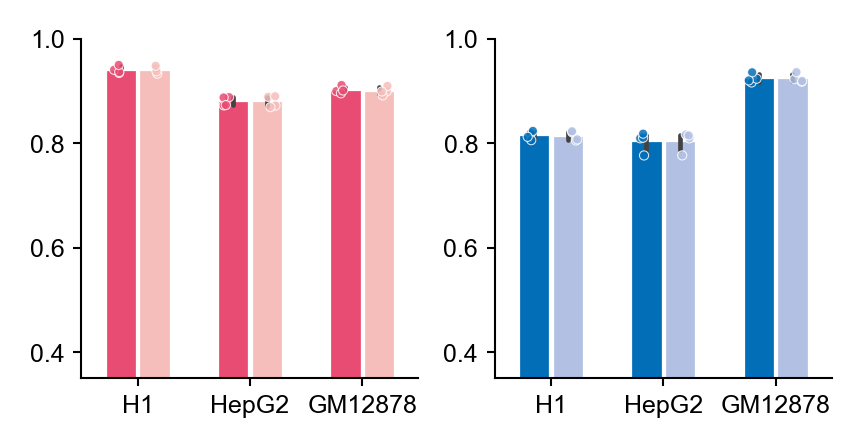

In [53]:

import matplotlib.patches as mpatches

fig, ax = plt.subplots(1, 2, constrained_layout=True, figsize=(7/2.54, 3.5/2.54))
order = pd.Index(["E003","E118","E116"],name='marks')
hue_order = pd.Index(["bf_label","bs_label"],name='target')


# 关键修改：横坐标缩小 100 倍

print(data)
palette = ['#E94C72',"#F6BEBB"]
target_data = data[data['target']=='bf_label']
hue_order = ['origin','random_selected']
sns.barplot(data=target_data,x='eid',y='auc',
                 linewidth=0.3,
                 ax=ax[0],order=order,hue='tss',hue_order=hue_order,palette=palette,
                 gap=0.1,width=0.6,alpha=1.0,saturation=1)

sns.stripplot(
    data=target_data,
    x="eid",
    y="auc",
    hue='tss',
    order=order,
    hue_order=hue_order,
    palette=palette,
    dodge=True,
    jitter=0.08,
    size=2.2,
    alpha=0.85,
    linewidth=0.25,
    edgecolor="white",
    ax=ax[0],
    legend=False,
)

# Show the plot
ax[0].set_ylabel("")
ax[0].set_xlabel("")
ax[0].set_ylim(ymin=0.35, ymax=1.0)
ax[0].legend().remove()
ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],rotation=0,)
# ax.set_title('AUC (4-fold CV)\nlabels from txburst')

legend_patches = [
    mpatches.Patch(color=palette[0], label='BF'),
    mpatches.Patch(color=palette[1], label='BS'),
]

target_data = data[data['target']=='bs_label']
print(data)
palette = ["#036EB8","#B2C1E3"]
hue_order = ['origin','random_selected']
sns.barplot(data=target_data,x='eid',y='auc',
                 linewidth=0.3,
                 ax=ax[1],order=order,hue='tss',hue_order=hue_order,palette=palette,
                 gap=0.1,width=0.6,alpha=1.0,saturation=1)

sns.stripplot(
    data=target_data,
    x="eid",
    y="auc",
    hue='tss',
    order=order,
    hue_order=hue_order,
    palette=palette,
    dodge=True,
    jitter=0.08,
    size=2.2,
    alpha=0.85,
    linewidth=0.25,
    edgecolor="white",
    ax=ax[1],
    legend=False,
)
# Show the plot
ax[1].set_ylabel("")
ax[1].set_xlabel("")
ax[1].set_ylim(ymin=0.35, ymax=1.0)
ax[1].legend().remove()
ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],rotation=0,)
# ax.set_title("AUC (4-fold CV)\nlabels from DeepTX")

legend_patches = [
    mpatches.Patch(color=palette[0], label='BF'),
    mpatches.Patch(color=palette[1], label='BS'),
]


fig.legend().remove()
plt.savefig(f'benchmarks/revised_v2/reviewer1/figures/random_select_tss_performence_txburst.pdf', format='pdf', bbox_inches='tight')


plt.show()

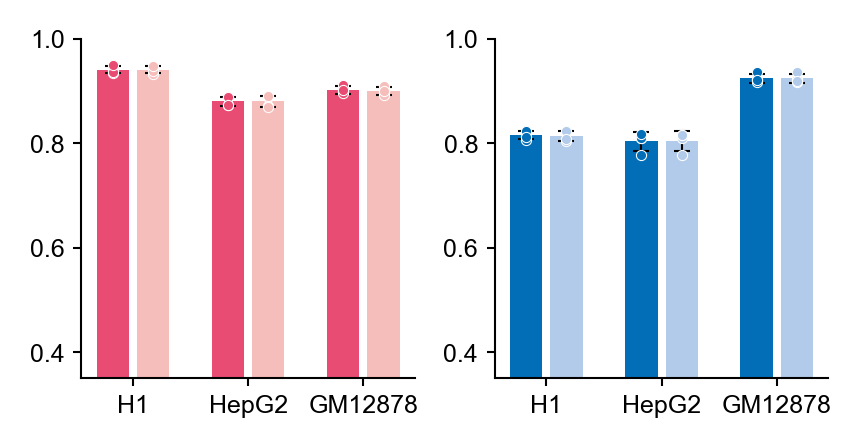

In [54]:
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    1, 2,
    constrained_layout=True,
    figsize=(7/2.54, 3.5/2.54)
)

order = pd.Index(["E003","E118","E116"], name='marks')

# =========================================================
# GLOBAL GEOMETRY CONTROL
# =========================================================
x_base = np.arange(len(order))
hue_spacing = 0.35
bar_width = 0.28

# =========================================================
# COLOR SYSTEM (semantic 2x2)
# =========================================================
color_map = {
    ('origin', 'bf_label'): "#E94C72",
    ('random_selected', 'bf_label'): "#F6BEBB",
    ('origin', 'bs_label'): "#036EB8",
    ('random_selected', 'bs_label'): "#B3CBEA",
}

hue_order = ['origin', 'random_selected']
offsets = np.linspace(-hue_spacing/2, hue_spacing/2, len(hue_order))


# =========================================================
# LEFT PANEL (BF)
# =========================================================
target_data = data[data['target'] == 'bf_label']

summary = target_data.groupby(['eid', 'tss'])['auc'].agg(['mean', 'std']).reset_index()

for i, hue in enumerate(hue_order):

    sub = summary[summary['tss'] == hue]

    means = np.array([sub[sub['eid'] == eid]['mean'].values[0] for eid in order])
    stds  = np.array([sub[sub['eid'] == eid]['std'].values[0] for eid in order])

    xpos = x_base + offsets[i]

    bar_colors = [color_map[(hue, 'bf_label')] for _ in order]

    ax[0].bar(
        xpos,
        means,
        width=bar_width,
        color=bar_colors,
        alpha=1.0,
        linewidth=0.0,
        edgecolor='none'
    )

    ax[0].errorbar(
        xpos,
        means,
        yerr=stds,
        fmt='none',
        ecolor='black',
        elinewidth=0.5,
        capsize=2,
        capthick=0.5,
        zorder=2
    )

# dot
for i, hue in enumerate(hue_order):

    sub_raw = target_data[target_data['tss'] == hue]

    x = np.array([
        np.where(order == eid)[0][0]
        for eid in sub_raw['eid']
    ]) + offsets[i]

    ax[0].scatter(
        x,
        sub_raw['auc'].values,
        s=6,
        color=color_map[(hue, 'bf_label')],
        alpha=1.0,
        edgecolor="white",
        linewidth=0.25,
        zorder=3
    )

ax[0].set_ylim(0.35, 1.0)
ax[0].set_xticks(x_base)
ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order], rotation=0)
ax[0].set_ylabel("")


# =========================================================
# RIGHT PANEL (BS)
# =========================================================
target_data = data[data['target'] == 'bs_label']

summary = target_data.groupby(['eid', 'tss'])['auc'].agg(['mean', 'std']).reset_index()

for i, hue in enumerate(hue_order):

    sub = summary[summary['tss'] == hue]

    means = np.array([sub[sub['eid'] == eid]['mean'].values[0] for eid in order])
    stds  = np.array([sub[sub['eid'] == eid]['std'].values[0] for eid in order])

    xpos = x_base + offsets[i]

    bar_colors = [color_map[(hue, 'bs_label')] for _ in order]

    ax[1].bar(
        xpos,
        means,
        width=bar_width,
        color=bar_colors,
        alpha=1.0,
        linewidth=0.0,
        edgecolor='none'
    )

    ax[1].errorbar(
        xpos,
        means,
        yerr=stds,
        fmt='none',
        ecolor='black',
        elinewidth=0.5,
        capsize=2,
        capthick=0.5,
        zorder=2
    )

# dot
for i, hue in enumerate(hue_order):

    sub_raw = target_data[target_data['tss'] == hue]

    x = np.array([
        np.where(order == eid)[0][0]
        for eid in sub_raw['eid']
    ]) + offsets[i]

    ax[1].scatter(
        x,
        sub_raw['auc'].values,
        s=6,
        color=color_map[(hue, 'bs_label')],
        alpha=1.0,
        edgecolor="white",
        linewidth=0.25,
        zorder=3
    )

ax[1].set_ylim(0.35, 1.0)
ax[1].set_xticks(x_base)
ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order], rotation=0)
ax[1].set_ylabel("")


# =========================================================
# LEGEND
# =========================================================
legend_patches = [
    mpatches.Patch(color="#E94C72", label='BF (origin)'),
    mpatches.Patch(color="#F6BEBB", label='BF (random)'),
    mpatches.Patch(color="#036EB8", label='BS (origin)'),
    mpatches.Patch(color="#B3CBEA", label='BS (random)'),
]

fig.legend(handles=legend_patches, loc='upper center', ncol=2, frameon=False).remove()

fig.savefig(
    'benchmarks/revised_v2/reviewer1/figures/random_select_tss_performence_txburst.pdf',
    format='pdf',
    bbox_inches='tight'
)

plt.show()

# Deeptx

In [55]:
data = pd.DataFrame()

for eid in ['E003','E116','E118']:
    pred_labeled_df = pd.read_csv(f'benchmarks/revised_v2/reviewer1/results/random_tss_selected_gene_predictions_by_fold_{eid}_deeptx.csv')

    indicator = compute_auc_table(pred_labeled_df, eid)
    data = pd.concat([data,indicator], axis=0)

data['tss'] = 'random_selected'
data2 = pd.read_csv('extra/results/bs_bf_deeptx_indicators.csv')
data2['tss'] = 'origin'
data = pd.concat([data,data2],axis=0)
data['auc'] = data['auc'] / 100


     eid  fold       auc    target              tss
0   E003     0  0.784958  bs_label  random_selected
1   E003     0  0.940891  bf_label  random_selected
2   E003     1  0.793098  bs_label  random_selected
3   E003     1  0.950889  bf_label  random_selected
4   E003     2  0.803493  bs_label  random_selected
5   E003     2  0.954301  bf_label  random_selected
6   E003     3  0.789389  bs_label  random_selected
7   E003     3  0.955775  bf_label  random_selected
0   E116     0  0.781452  bs_label  random_selected
1   E116     0  0.967827  bf_label  random_selected
2   E116     1  0.778493  bs_label  random_selected
3   E116     1  0.964827  bf_label  random_selected
4   E116     2  0.799210  bs_label  random_selected
5   E116     2  0.961023  bf_label  random_selected
6   E116     3  0.771536  bs_label  random_selected
7   E116     3  0.961248  bf_label  random_selected
0   E118     0  0.810555  bs_label  random_selected
1   E118     0  0.929637  bf_label  random_selected
2   E118    

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_9707/4122437270.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],rotation=0,)
/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_9707/4122437270.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],rotation=0,)


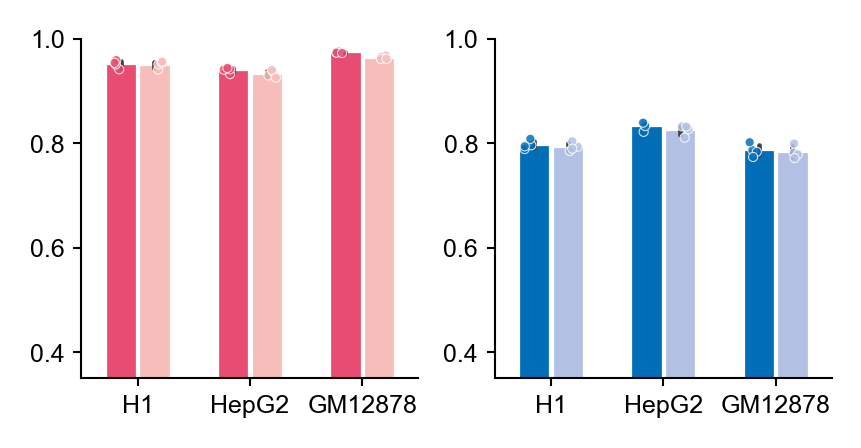

In [56]:

import matplotlib.patches as mpatches

fig, ax = plt.subplots(1, 2, constrained_layout=True, figsize=(7/2.54, 3.5/2.54))
order = pd.Index(["E003","E118","E116"],name='marks')
hue_order = pd.Index(["bf_label","bs_label"],name='target')


# 关键修改：横坐标缩小 100 倍

print(data)
palette = ['#E94C72',"#F6BEBB"]
target_data = data[data['target']=='bf_label']
hue_order = ['origin','random_selected']
sns.barplot(data=target_data,x='eid',y='auc',
                 linewidth=0.3,
                 ax=ax[0],order=order,hue='tss',hue_order=hue_order,palette=palette,
                 gap=0.1,width=0.6,alpha=1.0,saturation=1)

sns.stripplot(
    data=target_data,
    x="eid",
    y="auc",
    hue='tss',
    order=order,
    hue_order=hue_order,
    palette=palette,
    dodge=True,
    jitter=0.08,
    size=2.2,
    alpha=0.85,
    linewidth=0.25,
    edgecolor="white",
    ax=ax[0],
    legend=False,
)

# Show the plot
ax[0].set_ylabel("")
ax[0].set_xlabel("")
ax[0].set_ylim(ymin=0.35, ymax=1.0)
ax[0].legend().remove()
ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],rotation=0,)
# ax.set_title('AUC (4-fold CV)\nlabels from txburst')

legend_patches = [
    mpatches.Patch(color=palette[0], label='BF'),
    mpatches.Patch(color=palette[1], label='BS'),
]

target_data = data[data['target']=='bs_label']
print(data)
palette = ["#036EB8","#B2C1E3"]
hue_order = ['origin','random_selected']
sns.barplot(data=target_data,x='eid',y='auc',
                 linewidth=0.3,
                 ax=ax[1],order=order,hue='tss',hue_order=hue_order,palette=palette,
                 gap=0.1,width=0.6,alpha=1.0,saturation=1)

sns.stripplot(
    data=target_data,
    x="eid",
    y="auc",
    hue='tss',
    order=order,
    hue_order=hue_order,
    palette=palette,
    dodge=True,
    jitter=0.08,
    size=2.2,
    alpha=0.85,
    linewidth=0.25,
    edgecolor="white",
    ax=ax[1],
    legend=False,
)
# Show the plot
ax[1].set_ylabel("")
ax[1].set_xlabel("")
ax[1].set_ylim(ymin=0.35, ymax=1.0)
ax[1].legend().remove()
ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order],rotation=0,)
# ax.set_title("AUC (4-fold CV)\nlabels from DeepTX")

legend_patches = [
    mpatches.Patch(color=palette[0], label='BF'),
    mpatches.Patch(color=palette[1], label='BS'),
]


fig.legend().remove()
plt.savefig(f'benchmarks/revised_v2/reviewer1/figures/random_select_tss_performence_deeptx.pdf', format='pdf', bbox_inches='tight')

plt.show()

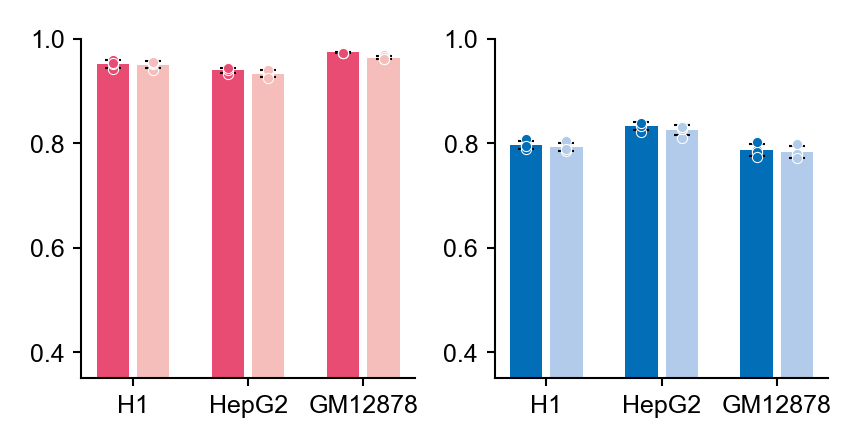

In [57]:
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    1, 2,
    constrained_layout=True,
    figsize=(7/2.54, 3.5/2.54)
)

order = pd.Index(["E003","E118","E116"], name='marks')

# =========================================================
# GLOBAL GEOMETRY CONTROL
# =========================================================
x_base = np.arange(len(order))
hue_spacing = 0.35
bar_width = 0.28

# =========================================================
# COLOR SYSTEM (semantic 2x2)
# =========================================================
color_map = {
    ('origin', 'bf_label'): "#E94C72",
    ('random_selected', 'bf_label'): "#F6BEBB",
    ('origin', 'bs_label'): "#036EB8",
    ('random_selected', 'bs_label'): "#B3CBEA",
}

hue_order = ['origin', 'random_selected']
offsets = np.linspace(-hue_spacing/2, hue_spacing/2, len(hue_order))


# =========================================================
# LEFT PANEL (BF)
# =========================================================
target_data = data[data['target'] == 'bf_label']

summary = target_data.groupby(['eid', 'tss'])['auc'].agg(['mean', 'std']).reset_index()

for i, hue in enumerate(hue_order):

    sub = summary[summary['tss'] == hue]

    means = np.array([sub[sub['eid'] == eid]['mean'].values[0] for eid in order])
    stds  = np.array([sub[sub['eid'] == eid]['std'].values[0] for eid in order])

    xpos = x_base + offsets[i]

    bar_colors = [color_map[(hue, 'bf_label')] for _ in order]

    ax[0].bar(
        xpos,
        means,
        width=bar_width,
        color=bar_colors,
        alpha=1.0,
        linewidth=0.0,
        edgecolor='none'
    )

    ax[0].errorbar(
        xpos,
        means,
        yerr=stds,
        fmt='none',
        ecolor='black',
        elinewidth=0.5,
        capsize=2,
        capthick=0.5,
        zorder=2
    )

# dot
for i, hue in enumerate(hue_order):

    sub_raw = target_data[target_data['tss'] == hue]

    x = np.array([
        np.where(order == eid)[0][0]
        for eid in sub_raw['eid']
    ]) + offsets[i]

    ax[0].scatter(
        x,
        sub_raw['auc'].values,
        s=6,
        color=color_map[(hue, 'bf_label')],
        alpha=1.0,
        edgecolor="white",
        linewidth=0.25,
        zorder=3
    )

ax[0].set_ylim(0.35, 1.0)
ax[0].set_xticks(x_base)
ax[0].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order], rotation=0)
ax[0].set_ylabel("")


# =========================================================
# RIGHT PANEL (BS)
# =========================================================
target_data = data[data['target'] == 'bs_label']

summary = target_data.groupby(['eid', 'tss'])['auc'].agg(['mean', 'std']).reset_index()

for i, hue in enumerate(hue_order):

    sub = summary[summary['tss'] == hue]

    means = np.array([sub[sub['eid'] == eid]['mean'].values[0] for eid in order])
    stds  = np.array([sub[sub['eid'] == eid]['std'].values[0] for eid in order])

    xpos = x_base + offsets[i]

    bar_colors = [color_map[(hue, 'bs_label')] for _ in order]

    ax[1].bar(
        xpos,
        means,
        width=bar_width,
        color=bar_colors,
        alpha=1.0,
        linewidth=0.0,
        edgecolor='none'
    )

    ax[1].errorbar(
        xpos,
        means,
        yerr=stds,
        fmt='none',
        ecolor='black',
        elinewidth=0.5,
        capsize=2,
        capthick=0.5,
        zorder=2
    )

# dot
for i, hue in enumerate(hue_order):

    sub_raw = target_data[target_data['tss'] == hue]

    x = np.array([
        np.where(order == eid)[0][0]
        for eid in sub_raw['eid']
    ]) + offsets[i]

    ax[1].scatter(
        x,
        sub_raw['auc'].values,
        s=6,
        color=color_map[(hue, 'bs_label')],
        alpha=1.0,
        edgecolor="white",
        linewidth=0.25,
        zorder=3
    )

ax[1].set_ylim(0.35, 1.0)
ax[1].set_xticks(x_base)
ax[1].set_xticklabels([EIDS_TO_CELLTYPES[eid] for eid in order], rotation=0)
ax[1].set_ylabel("")


# =========================================================
# LEGEND
# =========================================================
legend_patches = [
    mpatches.Patch(color="#E94C72", label='BF (origin)'),
    mpatches.Patch(color="#F6BEBB", label='BF (random)'),
    mpatches.Patch(color="#036EB8", label='BS (origin)'),
    mpatches.Patch(color="#B3CBEA", label='BS (random)'),
]

fig.legend(handles=legend_patches, loc='upper center', ncol=2, frameon=False).remove()

fig.savefig(
    'benchmarks/revised_v2/reviewer1/figures/random_select_tss_performence_deeptx.pdf',
    format='pdf',
    bbox_inches='tight'
)

plt.show()

# prediction analysis

In [16]:
eid = 'E003'
pred_labeled_df_random_tss = pd.read_csv(f'benchmarks/revised_v2/reviewer1/results/random_tss_selected_gene_predictions_by_fold_{eid}.csv')
pred_labeled_df_origin = pd.read_csv(f'extra/results/predictions_bs_bf.csv')
pred_labeled_df_origin = pred_labeled_df_origin[pred_labeled_df_origin['eid']==eid]


In [17]:
pred_labeled_df_random_tss[pred_labeled_df_random_tss['n_tss_unique']>=5]

,gene_id,chrom,start,end,strand,selected_tss,selected_tss_index,selected_tss_type,first_chrom,first_start,...,n_tss_unique,fold,bs_label_score,bs_label_pred,bf_label_score,bf_label_pred,eid,checkpoint,bs_label,bf_label
77,ENSG00000143570,chr1,153940660,153940661,-,153940660,2,alternative_tss_excluding_first,chr1,153936013,...,5,1,0.750349,1,0.968190,1,E003,checkpoints/E003.1.bs_bf_para.model.pt,0,1
92,ENSG00000143740,chr1,227923134,227923135,+,227923134,4,alternative_tss_excluding_first,chr1,227916217,...,5,1,0.803632,1,0.925410,1,E003,checkpoints/E003.1.bs_bf_para.model.pt,1,1
112,ENSG00000143147,chr1,168105945,168105946,-,168105945,4,alternative_tss_excluding_first,chr1,168106905,...,5,1,0.720680,1,0.629392,1,E003,checkpoints/E003.1.bs_bf_para.model.pt,1,1
173,ENSG00000117602,chr1,24828832,24828833,+,24828832,2,alternative_tss_excluding_first,chr1,24829324,...,6,1,0.746803,1,0.816665,1,E003,checkpoints/E003.1.bs_bf_para.model.pt,1,1
181,ENSG00000118197,chr1,200639126,200639127,-,200639126,4,alternative_tss_excluding_first,chr1,200639035,...,5,1,0.817881,1,0.971363,1,E003,checkpoints/E003.1.bs_bf_para.model.pt,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14229,ENSG00000169933,chrX,12516797,12516798,+,12516797,3,alternative_tss_excluding_first,chrX,11840556,...,6,0,0.029623,0,0.022829,0,E003,checkpoints/E003.0.bs_bf_para.model.pt,0,0
14333,ENSG00000130822,chrX,152939139,152939140,-,152939139,4,alternative_tss_excluding_first,chrX,152939816,...,5,0,0.231274,0,0.056084,0,E003,checkpoints/E003.0.bs_bf_para.model.pt,0,0
14374,ENSG00000182378,chrX,200143,200144,+,200143,2,alternative_tss_excluding_first,chrY,143021,...,5,0,0.668277,1,0.939937,1,E003,checkpoints/E003.0.bs_bf_para.model.pt,0,1
14387,ENSG00000165246,chrY,16634494,16634495,+,16634494,1,alternative_tss_excluding_first,chrY,16733899,...,6,1,0.695248,1,0.952915,1,E003,checkpoints/E003.1.bs_bf_para.model.pt,1,1


In [18]:
pred_labeled_df_origin
meta_data = pd.read_csv('./extra/datasets/processed/v2/meta_datasets/meta_data_E003.csv')

pred_labeled_df_origin = pd.merge(pred_labeled_df_origin, meta_data, on=['gene_id','eid'])
pred_labeled_df_origin

,gene_id,bs_label_label,bs_label_score,bs_label_pred,bf_label_label,bf_label_score,bf_label_pred,fold,eid,chrom,...,gene_name,bulk_exp,mean,cv,bulk_exp_label,sc_exp_label,bs_label,bf_label,cv_label,mean_label
0,ENSG00000083520,1,0.815917,1,1,0.991244,1,0,E003,chr13,...,DIS3,14.212,6.081799,5.099118,1,1,1,1,1,1
1,ENSG00000167769,0,0.032607,0,0,0.015112,0,0,E003,chr19,...,ACER1,0.011,0.000013,0.000000,0,0,0,0,0,0
2,ENSG00000177989,0,0.421529,0,0,0.323850,0,0,E003,chr22,...,ODF3B,0.079,0.000013,0.000000,0,0,0,0,0,0
3,ENSG00000173679,0,0.010599,0,0,0.007286,0,0,E003,chr9,...,OR1L1,0.000,0.000013,0.000000,0,0,0,0,0,0
4,ENSG00000213967,0,0.097868,0,0,0.078572,0,0,E003,chr19,...,ZNF726,0.943,0.000013,0.000000,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14415,ENSG00000064989,1,0.547398,1,0,0.417275,0,3,E003,chr2,...,CALCRL,1.583,0.137032,112.809875,0,0,1,0,1,0
14416,ENSG00000177143,0,0.092005,0,0,0.067594,0,3,E003,chr18,...,CETN1,0.000,0.000013,0.000000,0,0,0,0,0,0
14417,ENSG00000240423,0,0.043411,0,0,0.045655,0,3,E003,chr3,...,LINC00636,0.008,0.000013,0.000000,0,0,0,0,0,0
14418,ENSG00000163214,0,0.839123,1,1,0.982441,1,3,E003,chr2,...,DHX57,8.316,3.592305,4.954408,1,1,0,1,0,1


In [19]:
pred_labeled_df_origin[pred_labeled_df_origin['gene_id']=='ENSG00000143319'][['gene_id','start','end','bf_label_score','bs_label_score']]

,gene_id,start,end,bf_label_score,bs_label_score
4795,ENSG00000143319,156698231,156698232,0.985258,0.817931


# multi TSS analysis

In [20]:
import pickle
import numpy as np
from pathlib import Path
ensg2tss_path = Path("extra/datasets/annotations/ensg2tss.pickle")

with open(ensg2tss_path, "rb") as f:
    ensg2tss = pickle.load(f)



In [21]:
rows = []

for gene_id, tss_list in ensg2tss.items():
    if len(tss_list) == 0:
        continue

    # 按完整 TSS tuple 去重，并保持原始顺序
    unique_tss_list = []
    seen = set()

    for item in tss_list:
        chrom, start, end, strand = item
        key = (chrom, int(start), int(end), strand)

        if key in seen:
            continue

        seen.add(key)
        unique_tss_list.append(key)

    if len(unique_tss_list) == 0:
        continue

    # 第一个 unique TSS 作为 reference TSS
    first_chrom, first_start, first_end, first_strand = unique_tss_list[0]
    first_tss = int(first_start)

    distances = []

    # 从第二个 unique TSS 开始计算距离
    for chrom, start, end, strand in unique_tss_list[1:]:
        # 只比较同一染色体、同一链
        if chrom != first_chrom or strand != first_strand:
            continue

        tss = int(start)
        abs_distance = abs(tss - first_tss)
        distances.append(abs_distance)

    # 如果只有一个 unique TSS，或者后续 TSS 都不在同一染色体/同一链，则距离设为 0
    if len(distances) == 0:
        mean_dist = 0
        median_dist = 0
        max_dist = 0
    else:
        mean_dist = np.mean(distances)
        median_dist = np.median(distances)
        max_dist = np.max(distances)

    rows.append({
        "gene_id": gene_id,
        "n_tss_raw": len(tss_list),
        "n_tss_unique": len(unique_tss_list),
        "n_compared_tss": len(distances),
        "first_chrom": first_chrom,
        "first_strand": first_strand,
        "first_tss": first_tss,
        "mean_abs_distance_to_first_tss_bp": mean_dist,
        "median_abs_distance_to_first_tss_bp": median_dist,
        "max_abs_distance_to_first_tss_bp": max_dist,
    })

gene_tss_distance = pd.DataFrame(rows)

gene_tss_distance = gene_tss_distance.sort_values(
    "mean_abs_distance_to_first_tss_bp",
    ascending=False
).reset_index(drop=True)



eid = 'E003'

meta_data = pd.read_csv(f'./extra/datasets/processed/v2/meta_datasets/meta_data_{eid}.csv')[['gene_id','expression']]

gene_tss_distance = pd.merge(gene_tss_distance,meta_data,on='gene_id')

In [22]:
import pandas as pd

# 阈值分组：左闭右开/右闭这里用 <= 解释更直观
bins = [-1, 500, 1000, 2000, 5000, 10000, 20000, float("inf")]
labels = [
    "<=500",
    "500-1000",
    "1000-2000",
    "2000-5000",
    "5000-10000",
    "10000-20000",
    ">20000",
]

gene_tss_distance["mean_abs_distance_bin"] = pd.cut(
    gene_tss_distance["mean_abs_distance_to_first_tss_bp"],
    bins=bins,
    labels=labels,
    right=True
)

threshold_summary = (
    gene_tss_distance["mean_abs_distance_bin"]
    .value_counts()
    .reindex(labels)
    .reset_index()
)

threshold_summary.columns = ["mean_abs_distance_bin", "gene_count"]
threshold_summary["fraction"] = (
    threshold_summary["gene_count"] / threshold_summary["gene_count"].sum()
)

threshold_summary

,mean_abs_distance_bin,gene_count,fraction
0,<=500,11602,0.804577
1,500-1000,561,0.038904
2,1000-2000,319,0.022122
3,2000-5000,382,0.026491
4,5000-10000,331,0.022954
5,10000-20000,340,0.023578
6,>20000,885,0.061373


## mean distance per gene

/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_9707/584213011.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


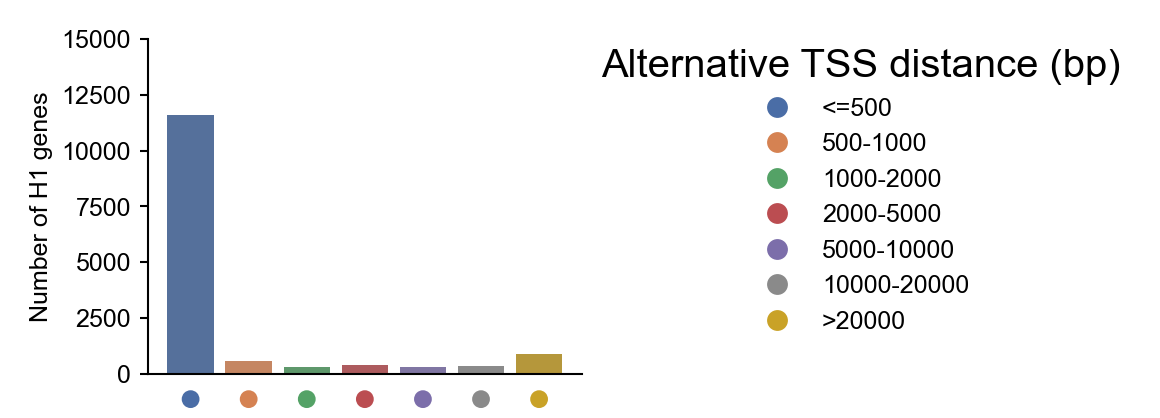

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

labels = [
    "<=500",
    "500-1000",
    "1000-2000",
    "2000-5000",
    "5000-10000",
    "10000-20000",
    ">20000",
]

COLOR_TYPES = {
    "<=500": "#4A6DA6",
    "500-1000": "#D58252",
    "1000-2000": "#54A266",
    "2000-5000": "#BB4D51",
    "5000-10000": "#7C6EAA",
    "10000-20000": "#8A8A8A",
    ">20000": "#C9A227",
}

plot_df = threshold_summary.copy()

# 确保类别顺序固定
plot_df["mean_abs_distance_bin"] = pd.Categorical(
    plot_df["mean_abs_distance_bin"],
    categories=labels,
    ordered=True,
)

plot_df = plot_df.sort_values("mean_abs_distance_bin")

fig, ax = plt.subplots(figsize=(7 / 2.54, 4 / 2.54))

sns.barplot(
    data=plot_df,
    x="mean_abs_distance_bin",
    y="gene_count",
    order=labels,
    palette=[COLOR_TYPES[label] for label in labels],
    ax=ax,
    edgecolor="none",
)

# 隐藏 x 轴类别文字，仅保留彩色圆点
ax.tick_params(axis="x", length=0, labelbottom=False)

# 用彩色圆点表示 x 轴类别
x_positions = ax.get_xticks()

ax.scatter(
    x_positions,
    [-0.075] * len(x_positions),
    s=12,
    c=[COLOR_TYPES[label] for label in labels],
    marker="o",
    transform=ax.get_xaxis_transform(),
    clip_on=False,
    zorder=5,
)

# 轴标签
ax.set_xlabel("")
ax.set_ylabel(f"Number of {EIDS_TO_CELLTYPES[eid]} genes")
ax.set_ylim(0,15000)

# 去掉上、右边框
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# 添加 legend，避免圆点无法解读
legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor=COLOR_TYPES[label],
        markeredgecolor="none",
        markersize=5,
        label=label,
    )
    for label in labels
]

ax.legend(
    handles=legend_handles,
    title="Alternative TSS distance (bp)",
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0,
)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18, right=0.72)
plt.savefig(f'benchmarks/revised_v2/reviewer1/figures/n_tss_avg_distance_{eid}.eps', format='eps', bbox_inches='tight')

plt.show()

## pie plot

In [24]:
import pandas as pd

rows = []

for gene_id, tss_list in ensg2tss.items():
    # 按完整 tuple 去重，并保持原始顺序
    unique_tss_list = []
    seen = set()

    for item in tss_list:
        chrom, start, end, strand = item
        key = (chrom, int(start), int(end), strand)

        if key in seen:
            continue

        seen.add(key)
        unique_tss_list.append(key)

    rows.append({
        "gene_id": gene_id,
        "n_tss_raw": len(tss_list),
        "n_tss_unique": len(unique_tss_list),
    })

tss_count_df = pd.DataFrame(rows)

tss_count_df = tss_count_df.sort_values(
    ["n_tss_unique", "n_tss_raw"],
    ascending=[False, False]
).reset_index(drop=True)



tss_count_df = pd.merge(tss_count_df,meta_data,on='gene_id')
tss_count_df

,gene_id,n_tss_raw,n_tss_unique,expression
0,ENSG00000196628,46,14,14.569733
1,ENSG00000048740,36,12,5.074184
2,ENSG00000022267,16,12,5.448071
3,ENSG00000172995,59,11,0.000000
4,ENSG00000196482,20,11,0.192878
...,...,...,...,...
14415,ENSG00000259511,1,1,0.020772
14416,ENSG00000259518,1,1,0.000000
14417,ENSG00000259571,1,1,0.000000
14418,ENSG00000259642,1,1,0.575668


In [25]:
plot_df = tss_count_df.copy()

plot_df["n_tss_group"] = plot_df["n_tss_unique"].apply(
    lambda x: str(x) if x < 6 else ">5"
)

# 固定显示顺序
order = ["1", "2", "3", "4", "5", ">5"]

plot_df["n_tss_group"] = pd.Categorical(
    plot_df["n_tss_group"],
    categories=order,
    ordered=True
)

pie_df = (
    plot_df
    .groupby("n_tss_group", observed=False)
    .agg(
        gene_count=("gene_id", "count"),
        mean_expression=("expression", "mean"),
        median_expression=("expression", "median"),
    )
    .reset_index()
)

pie_df["fraction"] = pie_df["gene_count"] / pie_df["gene_count"].sum()

pie_df = pie_df.sort_values("n_tss_group").reset_index(drop=True)

pie_df

,n_tss_group,gene_count,mean_expression,median_expression,fraction
0,1,8969,5.412559,0.353116,0.621983
1,2,3568,6.824586,2.007418,0.247434
2,3,1172,8.556041,2.166172,0.081276
3,4,412,8.217013,2.548961,0.028571
4,5,168,5.857655,1.951039,0.011650
5,>5,131,7.911228,2.545994,0.009085


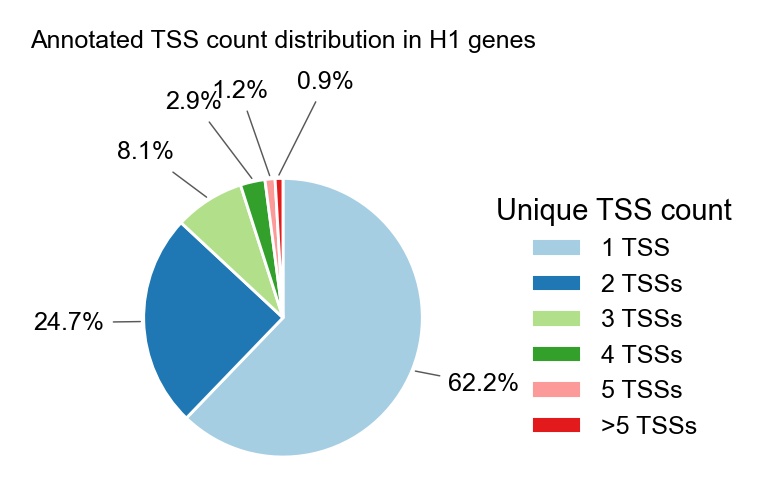

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Prepare labels and colors
# ------------------------------------------------------------

label_map = {
    "1": "1 TSS",
    "2": "2 TSSs",
    "3": "3 TSSs",
    "4": "4 TSSs",
    "5": "5 TSSs",
    ">5": ">5 TSSs",
}

eid_label_map = {
    "E003": "H1",
    "E116": "GM12878",
    "E118": "HepG2",
}

eid_label = eid_label_map.get(eid, eid)

plot_df = pie_df.copy()
plot_df["n_tss_group"] = plot_df["n_tss_group"].astype(str)
plot_df["n_tss_group_label"] = plot_df["n_tss_group"].map(label_map)

order = ["1", "2", "3", "4", "5", ">5"]
plot_df["n_tss_group"] = pd.Categorical(
    plot_df["n_tss_group"],
    categories=order,
    ordered=True,
)
plot_df = plot_df.sort_values("n_tss_group")

values = plot_df["gene_count"].to_numpy()
legend_labels = plot_df["n_tss_group_label"].to_list()

colors = [
    "#A6CEE3",  # 1 TSS
    "#1F78B4",  # 2 TSSs
    "#B2DF8A",  # 3 TSSs
    "#33A02C",  # 4 TSSs
    "#FB9A99",  # 5 TSSs
    "#E31A1C",  # >5 TSSs
]


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6.5 / 2.54, 4.8 / 2.54))

wedges, _ = ax.pie(
    values,
    labels=None,
    colors=colors[:len(values)],
    startangle=90,
    counterclock=False,
    radius=0.82,
    wedgeprops={
        "linewidth": 0.7,
        "edgecolor": "white",
    },
)

# ------------------------------------------------------------
# Percentage labels outside sectors
# ------------------------------------------------------------

total = values.sum()

# 手动错位，解决顶部小扇区标签重叠
manual_offsets = {
    "1": (0.00, 0.00),
    "2": (0.00, 0.00),
    "3": (-0.04, 0.03),
    "4": (-0.09, 0.08),
    "5": (0.03, 0.12),
    ">5": (0.12, 0.17),
}

for wedge, value, group in zip(wedges, values, plot_df["n_tss_group"].astype(str)):
    pct = 100 * value / total
    label = f"{pct:.1f}%"

    angle = (wedge.theta1 + wedge.theta2) / 2.0
    angle_rad = np.deg2rad(angle)

    x = np.cos(angle_rad)
    y = np.sin(angle_rad)

    # 大扇区离饼图近一些，小扇区远一些
    if pct >= 10:
        r_text = 1.05
    elif pct >= 3:
        r_text = 1.12
    else:
        r_text = 1.22

    dx, dy = manual_offsets.get(group, (0.0, 0.0))

    x_text = r_text * x + dx
    y_text = r_text * y + dy

    ha = "left" if x_text >= 0 else "right"

    ax.annotate(
        label,
        xy=(0.84 * x, 0.84 * y),
        xytext=(x_text, y_text),
        ha=ha,
        va="center",
        fontsize=6,
        arrowprops={
            "arrowstyle": "-",
            "lw": 0.35,
            "color": "0.35",
            "shrinkA": 0,
            "shrinkB": 0,
        },
    )

# ------------------------------------------------------------
# Title and legend
# ------------------------------------------------------------

ax.set_title(
    f"Annotated TSS count distribution in {eid_label} genes",
    # fontsize=7.5,
    pad=6,
    y=1.3
)

ax.legend(
    wedges,
    legend_labels,
    title="Unique TSS count",
    frameon=False,
    fontsize=6,
    title_fontsize=7,
    loc="center left",
    bbox_to_anchor=(1.08, 0.5),
    borderaxespad=0,
)

ax.axis("equal")

plt.tight_layout()

out_path = f"benchmarks/revised_v2/reviewer1/figures/n_tss_distribution_{eid}.eps"
plt.savefig(out_path, format="eps", bbox_inches="tight")
plt.show()

# Case analysis

In [27]:
tss_count_df

,gene_id,n_tss_raw,n_tss_unique,expression
0,ENSG00000196628,46,14,14.569733
1,ENSG00000048740,36,12,5.074184
2,ENSG00000022267,16,12,5.448071
3,ENSG00000172995,59,11,0.000000
4,ENSG00000196482,20,11,0.192878
...,...,...,...,...
14415,ENSG00000259511,1,1,0.020772
14416,ENSG00000259518,1,1,0.000000
14417,ENSG00000259571,1,1,0.000000
14418,ENSG00000259642,1,1,0.575668


In [28]:
import torch
import pandas as pd
import numpy as np
from pathlib import Path

from src.model.net import DeepBurst
from src.utils.tools import seed_everything
from src.utils.constants import DEVICE
from src.model.constants import get_config

from benchmarks.revised_v2.reviewer1.data_extractor import HistoneExtractor


# ============================================================
# 1. Basic configuration
# ============================================================

eid = "E003"
# gene_id = "ENSG00000117602"

ensg2tss_path = "extra/datasets/annotations/ensg2tss.pickle"
bigwig_dir = "extra/datasets/epigenetic/hg19"
meta_dir = Path("extra/datasets/processed/v2/meta_datasets")

config_path = "configs/default.yaml"
config = get_config(config_path)

seed = 42
seed_everything(seed)

remove_marks = None
if remove_marks:
    config["remove_marks"] = [remove_marks] if isinstance(remove_marks, str) else list(remove_marks)
else:
    config["remove_marks"] = []

config["marked_bin_idxes"] = []
config["masked_marks"] = []

n_feats_p = config["promoter_feats_basic_nums"] - len(config["remove_marks"])
d_emb = config["embed"]["d_model"]
d_head = config["d_head"]
embed_kws = config["embed"]

targets = ["bs_label", "bf_label"]
binsizes = [500]
bin_size = 500

strand_oriented = True

eid2celltype = {
    "E003": "H1",
    "E116": "GM12878",
    "E118": "HepG2",
}

celltype = eid2celltype.get(eid, eid)

print("eid:", eid)
print("celltype:", celltype)
# print("gene_id:", gene_id)
print("DEVICE:", DEVICE)

/Users/wanghan/miniconda3/envs/deepburst/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


eid: E003
celltype: H1
DEVICE: cpu


In [29]:
# ============================================================
# 2. Chromosome split logic
# Must match the training code
# ============================================================

def build_chromosome_splits():
    splits = {
        1: ["chr1", "chr6", "chr5", "chr8", "chr14", "chrY"],
        2: ["chr7", "chr10", "chr11", "chr12", "chr15", "chr21"],
        3: ["chr2", "chr3", "chr4", "chr16", "chr18", "chr20"],
        4: ["chr9", "chr13", "chr17", "chr19", "chr22", "chrX"],
    }

    chromosome_splits = {}
    for split_id, chroms in splits.items():
        for chrom in chroms:
            chromosome_splits[chrom] = split_id

    return chromosome_splits


CHROMOSOME_SPLITS = build_chromosome_splits()


def chrom_to_fold(chrom):
    """
    Match training code:

        val_genes = qs[(fold + 3) % 4]

    Therefore:
        fold 0 -> split 4
        fold 1 -> split 1
        fold 2 -> split 2
        fold 3 -> split 3

    So:
        split_id -> fold = split_id % 4
    """
    chrom = str(chrom)

    if chrom not in CHROMOSOME_SPLITS:
        raise ValueError(f"Unknown chromosome: {chrom}")

    split_id = CHROMOSOME_SPLITS[chrom]
    return split_id % 4

In [30]:
# ============================================================
# 3. Model loading
# ============================================================

def get_checkpoint_path(eid, fold, config, remove_marks=None):
    if remove_marks:
        remove_name = "_".join(config["remove_marks"])
        ckpt_path = f"checkpoints/{eid}.remove_{remove_name}.{fold}.bs_bf_para.model.pt"
    else:
        ckpt_path = f"checkpoints/{eid}.{fold}.bs_bf_para.model.pt"

    return ckpt_path


def build_deepburst_model():
    model = DeepBurst(
        n_feats_p,
        d_emb,
        d_head,
        embed_kws=embed_kws,
        binsizes=binsizes,
        seed=42,
        targets=targets,
    ).to(DEVICE)

    return model


def load_deepburst_model(eid, fold, config, remove_marks=None):
    model = build_deepburst_model()

    ckpt_path = get_checkpoint_path(
        eid=eid,
        fold=fold,
        config=config,
        remove_marks=remove_marks,
    )

    if not Path(ckpt_path).exists():
        raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt["net"])
    model.eval()

    return model, ckpt_path


def load_all_fold_models(eid, config, remove_marks=None, folds=(0, 1, 2, 3)):
    model_dict = {}

    for fold in folds:
        print(f"[Load model] eid={eid}, fold={fold}")

        model, ckpt_path = load_deepburst_model(
            eid=eid,
            fold=fold,
            config=config,
            remove_marks=remove_marks,
        )

        model_dict[int(fold)] = {
            "model": model,
            "checkpoint": ckpt_path,
        }

    return model_dict

In [31]:
# ============================================================
# 4. Tensor helpers
# ============================================================

def move_to_device(obj, device):
    if torch.is_tensor(obj):
        return obj.to(device)

    if isinstance(obj, dict):
        return {k: move_to_device(v, device) for k, v in obj.items()}

    if isinstance(obj, list):
        return [move_to_device(v, device) for v in obj]

    if isinstance(obj, tuple):
        return tuple(move_to_device(v, device) for v in obj)

    return obj

def make_model_inputs_from_X(X, bin_size=500):
    """
    Convert extracted histone matrix to DeepBurst input.

    X:
        np.ndarray, shape = (B, 80, 7)

    Return:
        model_inputs["promoter_feats"][500]:
            torch.Tensor, shape = (B, 1, 80, 7)
    """
    if not isinstance(X, np.ndarray):
        X = np.asarray(X)

    X_tensor = torch.from_numpy(X).float()

    if X_tensor.ndim != 3:
        raise ValueError(
            f"Expected X shape = (B, n_bins, n_marks), got {X_tensor.shape}"
        )

    model_inputs = {
        "promoter_feats": {
            bin_size: X_tensor.unsqueeze(1)
        }
    }

    return model_inputs


def parse_deepburst_output(out, targets=("bs_label", "bf_label")):
    """
    Follow validation logic:

        torch.chunk(out, len(targets), axis=-1)

    Each target has two logits.

    Output:
        bs_label_score, bs_label_pred,
        bf_label_score, bf_label_pred
    """
    pred_chunks = torch.chunk(out, len(targets), dim=-1)

    records = {}

    for target, logits in zip(targets, pred_chunks):
        score = logits.softmax(dim=1)[:, 1]
        pred = logits.argmax(dim=1)

        records[f"{target}_score"] = score.detach().cpu().numpy()
        records[f"{target}_pred"] = pred.detach().cpu().numpy()

    return pd.DataFrame(records)

In [32]:
# ============================================================
# 5. Initialize extractor
# ============================================================

extractor = HistoneExtractor(
    ensg2tss_path=ensg2tss_path,
    bigwig_dir=bigwig_dir,
    eid=eid,
    seed=seed,
    log1p=True,
)

In [33]:
# ============================================================
# 9. Load all fold models
# ============================================================

model_dict = load_all_fold_models(
    eid=eid,
    config=config,
    remove_marks=remove_marks,
    folds=(0, 1, 2, 3),
)

[Load model] eid=E003, fold=0
[Load model] eid=E003, fold=1
[Load model] eid=E003, fold=2
[Load model] eid=E003, fold=3


In [34]:
def predict_all_tss_for_gene(
    extractor,
    model_dict,
    eid,
    gene_id,
    unique=True,
    strand_oriented=True,
    bin_size=500,
    return_X=False,
):
    """
    Predict BF/BS scores for all annotated TSSs of one gene.

    Returns
    -------
    pred_all_tss_df:
        One row per TSS.

    X_all:
        Returned only when return_X=True.
        Shape = (n_tss, n_bins, n_marks).
    """
    celltype = eid2celltype.get(eid, eid)

    # ------------------------------------------------------------
    # 1. Get all TSSs
    # ------------------------------------------------------------
    tss_df = extractor.get_all_tss(
        gene_id,
        unique=unique,
        as_dataframe=True,
    ).reset_index(drop=True)

    if tss_df.empty:
        raise ValueError(f"No TSS found for gene_id={gene_id}")

    # ------------------------------------------------------------
    # 2. Extract matrix for each TSS
    # ------------------------------------------------------------
    X_list = []
    meta_list = []

    for _, row in tss_df.iterrows():
        X_tss, tss_meta = extractor.get_tss_matrix(
            tss=row,
            strand_oriented=strand_oriented,
            add_batch_dim=False,
            return_meta=True,
        )

        X_list.append(X_tss)
        meta_list.append(tss_meta)

    X_all = np.stack(X_list, axis=0).astype(np.float32)
    meta_df = pd.DataFrame(meta_list).reset_index(drop=True)

    # ------------------------------------------------------------
    # 3. Assign fold
    # ------------------------------------------------------------
    meta_df["fold"] = meta_df["chrom"].apply(chrom_to_fold).astype(int)

    # ------------------------------------------------------------
    # 4. Convert to DeepBurst input
    # X_all: (n_tss, 80, 7)
    # fold_x_all: (n_tss, 1, 80, 7)
    # ------------------------------------------------------------
    X_tensor = torch.from_numpy(X_all).float()
    fold_x_all = X_tensor.unsqueeze(1)

    # ------------------------------------------------------------
    # 5. Predict by fold
    # ------------------------------------------------------------
    all_pred_parts = []

    for fold, sub_meta in meta_df.groupby("fold", sort=False):
        fold = int(fold)

        if fold not in model_dict:
            raise KeyError(f"Fold {fold} not found in model_dict")

        model = model_dict[fold]["model"]
        ckpt_path = model_dict[fold]["checkpoint"]

        idx = torch.tensor(sub_meta.index.to_numpy(), dtype=torch.long)

        fold_x = fold_x_all[idx].to(DEVICE)

        model.eval()
        with torch.no_grad():
            out = model(fold_x)

        pred_part = parse_deepburst_output(
            out,
            targets=targets,
        )

        result_part = sub_meta.reset_index(drop=True).copy()
        result_part = pd.concat([result_part, pred_part], axis=1)

        result_part["eid"] = eid
        result_part["celltype"] = celltype
        result_part["checkpoint"] = ckpt_path

        all_pred_parts.append(result_part)

    pred_all_tss_df = (
        pd.concat(all_pred_parts, axis=0)
        .sort_values(["tss_index", "chrom", "start"])
        .reset_index(drop=True)
    )

    # ------------------------------------------------------------
    # 6. Reorder columns
    # ------------------------------------------------------------
    preferred_cols = [
        "eid",
        "celltype",
        "gene_id",
        "tss_index",
        "chrom",
        "start",
        "end",
        "strand",
        "tss",
        "is_first_tss",
        "distance_to_first_tss_bp",
        "n_tss_raw",
        "n_tss_unique",
        "fold",
        "bs_label_score",
        "bs_label_pred",
        "bf_label_score",
        "bf_label_pred",
        "checkpoint",
    ]

    existing_cols = [c for c in preferred_cols if c in pred_all_tss_df.columns]
    other_cols = [c for c in pred_all_tss_df.columns if c not in existing_cols]

    pred_all_tss_df = pred_all_tss_df[existing_cols + other_cols]

    if return_X:
        return pred_all_tss_df, X_all

    return pred_all_tss_df

In [35]:
# ============================================================
# Predict all TSSs of one gene
# ============================================================

gene_id = "ENSG00000196628"

pred_all_tss_df = predict_all_tss_for_gene(
    extractor=extractor,
    model_dict=model_dict,
    eid=eid,
    gene_id=gene_id,
    unique=True,
    strand_oriented=True,
    bin_size=500,
    return_X=False,
)

pred_all_tss_df[['gene_id', 'tss_index', 'chrom', 'start', 'end','strand', 'bs_label_score','bs_label_pred','bf_label_score','bf_label_pred']]

,gene_id,tss_index,chrom,start,end,strand,bs_label_score,bs_label_pred,bf_label_score,bf_label_pred
0,ENSG00000196628,0,chr18,53255423,53255424,-,0.672893,1,0.970940,1
1,ENSG00000196628,1,chr18,53303188,53303189,-,0.071837,0,0.055659,0
2,ENSG00000196628,2,chr18,53257042,53257043,-,0.704880,1,0.963219,1
3,ENSG00000196628,3,chr18,53255860,53255861,-,0.761194,1,0.988708,1
4,ENSG00000196628,4,chr18,53178003,53178004,-,0.610527,1,0.513574,1
5,ENSG00000196628,5,chr18,53071226,53071227,-,0.501179,1,0.310902,0
6,ENSG00000196628,6,chr18,53089528,53089529,-,0.631411,1,0.488923,0
7,ENSG00000196628,7,chr18,52989072,52989073,-,0.599977,1,0.322987,0
8,ENSG00000196628,8,chr18,52969891,52969892,-,0.545494,1,0.307331,0
9,ENSG00000196628,9,chr18,53253350,53253351,-,0.685594,1,0.938546,1


## case summary

In [36]:


# ------------------------------------------------------------
# 1. Convert wide table to long format
# ------------------------------------------------------------

plot_df = pred_all_tss_df.copy()

score_long_df = plot_df.melt(
    id_vars=[
        "gene_id",
        "tss_index",
        "chrom",
        "start",
        "end",
        "strand",
    ],
    value_vars=[
        "bf_label_score",
        "bs_label_score",
    ],
    var_name="target",
    value_name="score",
)

score_long_df["target"] = score_long_df["target"].map({
    "bf_label_score": "BF",
    "bs_label_score": "BS",
})

score_long_df["target"] = pd.Categorical(
    score_long_df["target"],
    categories=["BF", "BS"],
    ordered=True,
)

score_long_df.head()

,gene_id,tss_index,chrom,start,end,strand,target,score
0,ENSG00000196628,0,chr18,53255423,53255424,-,BF,0.970940
1,ENSG00000196628,1,chr18,53303188,53303189,-,BF,0.055659
2,ENSG00000196628,2,chr18,53257042,53257043,-,BF,0.963219
3,ENSG00000196628,3,chr18,53255860,53255861,-,BF,0.988708
4,ENSG00000196628,4,chr18,53178003,53178004,-,BF,0.513574


/var/folders/tg/cls39crs76x43ks_vyxx1cgr0000gn/T/ipykernel_9707/3719061301.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


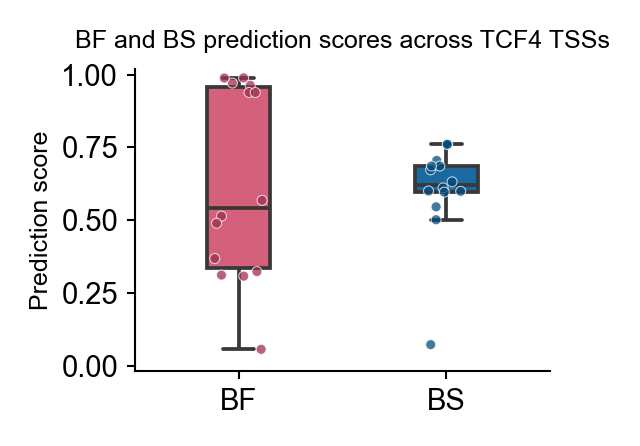

In [37]:
fig, ax = plt.subplots(figsize=(5 / 2.54, 4 / 2.54))

box_palette = {
    "BF": "#E94C72",
    "BS": "#036EB8",
}

point_palette = {
    "BF": "#9E2F4F",   # darker rose
    "BS": "#014C7F",   # darker blue
}

sns.boxplot(
    data=score_long_df,
    x="target",
    y="score",
    order=["BF", "BS"],
    width=0.3,
    showfliers=False,
    ax=ax,
    palette=box_palette,
    linewidth=0.9,
)

sns.stripplot(
    data=score_long_df,
    x="target",
    y="score",
    order=["BF", "BS"],
    hue="target",
    palette=point_palette,
    size=2.4,
    jitter=0.12,
    alpha=0.75,
    edgecolor="white",
    linewidth=0.25,
    ax=ax,
    legend=False,
)

ax.set_xlabel("")
ax.set_ylabel("Prediction score")
ax.set_ylim(-0.02, 1.02)

ax.set_title(
    "BF and BS prediction scores across TCF4 TSSs",
    pad=5,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="x", labelsize=7)
ax.tick_params(axis="y", labelsize=7)

plt.tight_layout()

out_path = f"benchmarks/revised_v2/reviewer1/figures/TCF4_prediction_scores.pdf"
plt.savefig(out_path, format="pdf", bbox_inches="tight")
plt.show()

In [38]:
tss_df = extractor.get_all_tss(
    gene_id,
    unique=True,
    as_dataframe=True,
)

tss_df

,gene_id,tss_index,chrom,start,end,strand,tss,is_first_tss,first_chrom,first_start,first_end,first_strand,first_tss,distance_to_first_tss_bp,n_tss_raw,n_tss_unique,is_unique_output
0,ENSG00000196628,0,chr18,53255423,53255424,-,53255423,True,chr18,53255423,53255424,-,53255423,0,46,14,True
1,ENSG00000196628,1,chr18,53303188,53303189,-,53303188,False,chr18,53255423,53255424,-,53255423,47765,46,14,True
2,ENSG00000196628,2,chr18,53257042,53257043,-,53257042,False,chr18,53255423,53255424,-,53255423,1619,46,14,True
3,ENSG00000196628,3,chr18,53255860,53255861,-,53255860,False,chr18,53255423,53255424,-,53255423,437,46,14,True
4,ENSG00000196628,4,chr18,53178003,53178004,-,53178003,False,chr18,53255423,53255424,-,53255423,77420,46,14,True
5,ENSG00000196628,5,chr18,53071226,53071227,-,53071226,False,chr18,53255423,53255424,-,53255423,184197,46,14,True
6,ENSG00000196628,6,chr18,53089528,53089529,-,53089528,False,chr18,53255423,53255424,-,53255423,165895,46,14,True
7,ENSG00000196628,7,chr18,52989072,52989073,-,52989072,False,chr18,53255423,53255424,-,53255423,266351,46,14,True
8,ENSG00000196628,8,chr18,52969891,52969892,-,52969891,False,chr18,53255423,53255424,-,53255423,285532,46,14,True
9,ENSG00000196628,9,chr18,53253350,53253351,-,53253350,False,chr18,53255423,53255424,-,53255423,2073,46,14,True


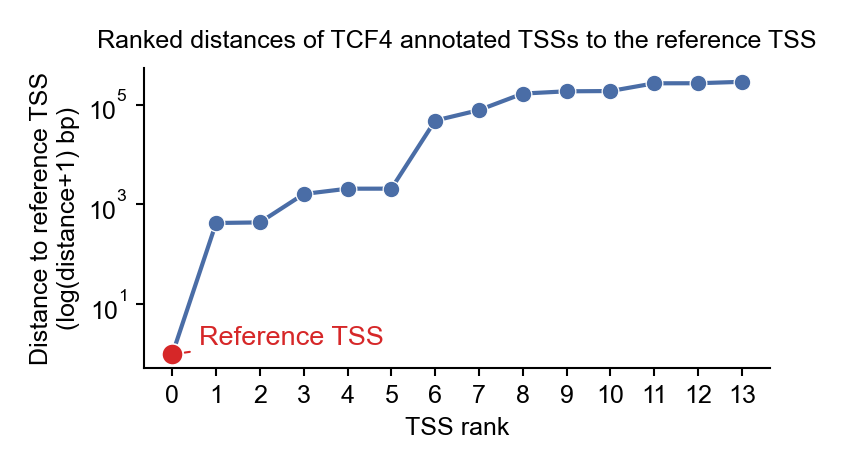

In [39]:
# ------------------------------------------------------------
# Log-scale version: sorted by distance
# ------------------------------------------------------------

plot_df = tss_df.copy()

plot_df["tss_index"] = plot_df["tss_index"].astype(int)
plot_df["distance_to_first_tss_bp"] = plot_df["distance_to_first_tss_bp"].astype(float)
plot_df["distance_plus1"] = plot_df["distance_to_first_tss_bp"] + 1

# 按距离从小到大排序；距离相同再按原始 tss_index 排序
plot_df = (
    plot_df
    .sort_values(["distance_to_first_tss_bp", "tss_index"])
    .reset_index(drop=True)
)

# 排序后的横坐标
plot_df["ranked_tss_index"] = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(7.0 / 2.54, 4.2 / 2.54))

# ------------------------------------------------------------
# Main line
# ------------------------------------------------------------

ax.plot(
    plot_df["ranked_tss_index"],
    plot_df["distance_plus1"],
    marker="o",
    markersize=4,
    linewidth=1.0,
    color="#4A6DA6",
    markerfacecolor="#4A6DA6",
    markeredgecolor="white",
    markeredgewidth=0.3,
    zorder=2,
)

# ------------------------------------------------------------
# Highlight reference TSS
# ------------------------------------------------------------

ref_row = plot_df.iloc[0]

ax.scatter(
    ref_row["ranked_tss_index"],
    ref_row["distance_plus1"],
    s=26,
    color="#D62728",
    edgecolor="white",
    linewidth=0.4,
    zorder=4,
)

ax.annotate(
    "Reference TSS",
    xy=(ref_row["ranked_tss_index"], ref_row["distance_plus1"]),
    xytext=(ref_row["ranked_tss_index"] + 0.6, ref_row["distance_plus1"] * 2.2),
    fontsize=6.5,
    color="#D62728",
    ha="left",
    va="center",
    arrowprops={
        "arrowstyle": "-",
        "lw": 0.5,
        "color": "#D62728",
        "shrinkA": 0,
        "shrinkB": 3,
    },
)

# ------------------------------------------------------------
# Axis style
# ------------------------------------------------------------

ax.set_yscale("log")

ax.set_xlabel("TSS rank")
ax.set_ylabel("Distance to reference TSS\n(log(distance+1) bp)")

ax.set_title(
    "Ranked distances of TCF4 annotated TSSs to the reference TSS",
    pad=5,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="x", )
ax.tick_params(axis="y", )

ax.set_xticks(plot_df["ranked_tss_index"].to_numpy())

plt.tight_layout()
out_path = f"benchmarks/revised_v2/reviewer1/figures/TCF4_TSSs_distance_ranking.pdf"
plt.savefig(out_path, format="pdf", bbox_inches="tight")
plt.show()